<a href="https://colab.research.google.com/github/aaryachauhan123/AI-ML-Learning/blob/main/SVC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import necessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


importing data set

In [ ]:
data = pd.read_csv('/content/wastee management')
#check for mission values
print(data.isnull().sum)
#handle missing values with mean()
data.fillna(data.mean(), inplace=True)

print(data.head())

<bound method DataFrame.sum of     waste_type  material_composition  recycling_potential  toxicity_level  \
0        False                 False                False           False   
1        False                 False                False           False   
2        False                 False                False           False   
3        False                 False                False           False   
4        False                 False                False           False   
..         ...                   ...                  ...             ...   
95       False                 False                False           False   
96       False                 False                False           False   
97       False                 False                False           False   
98       False                 False                False           False   
99       False                 False                False           False   

    management_strategy  
0                 

In [ ]:
data.shape

(100, 5)

In [ ]:
#defining features and target variable
X = data[['waste_type', 'material_composition', 'recycling_potential', 'toxicity_level']] #input feataures
y = data[['management_strategy']]  #target variable

spliting of data in to training and testing

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#set number of neighbours

model = SVC(kernel='rbf',C=1.0,gamma='scale')# kernel = linear lakhi to gamma nai nakhvanu accuracy par farak padse
model.fit(X_train,y_train)  #training of model starts here

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC()

In [ ]:
#we are prdicting values of target variable using X_test and storing it in y_pred variable
y_pred = model.predict(X_test)

In [ ]:
# Accuracy
#we are comparing y test with y predict to get the accuracy of predicted data.
accuracy = accuracy_score(y_test,y_pred)
print("accuracy :",accuracy)

accuracy : 0.9


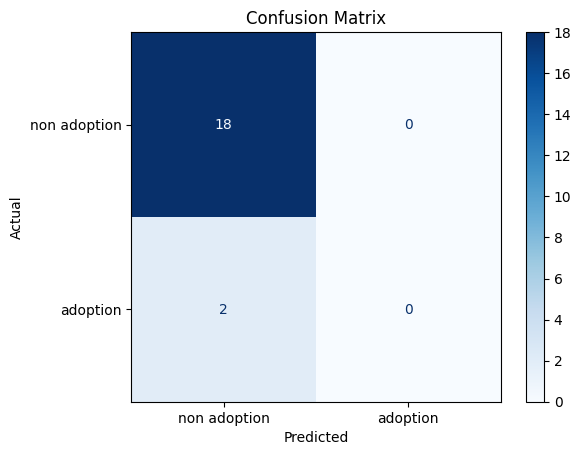

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap='Greens',
            xticklabels = ['Non Adoption', 'Adoption'],
            yticklabels = ['Non Adoption', 'Adoption'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
print("Confusion Matrix:")

In [ ]:
# Generate the classification report
# The classification report shows the precision, recall, f1-score, and support for each class.
# 'non adoption' corresponds to the target value 0, and 'adoption' corresponds to the target value 1.
report = classification_report(y_test, y_pred, target_names=['non adoption', 'adoption'])
print(report)

              precision    recall  f1-score   support

non adoption       0.90      1.00      0.95        18
    adoption       0.00      0.00      0.00         2

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
